In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway, shapiro
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.multicomp import MultiComparison

In [2]:
DRIVE_DIRECTORY = Path.cwd().parent / "data"
with open(os.path.join(DRIVE_DIRECTORY, "credit.pkl"), "rb") as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = (
        pickle.load(f)
    )

In [3]:
resultados_arvores = []
resultados_random_forest = []
resultados_knn = []
resultados_logistica = []
resultados_svm = []
# resultados_rede_neural = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    arvore = DecisionTreeClassifier(
        criterion="entropy", min_samples_leaf=1, min_samples_split=5, splitter="best"
    )
    random_forest = RandomForestClassifier(
        criterion="entropy", min_samples_leaf=1, min_samples_split=5, n_estimators=10
    )
    knn = KNeighborsClassifier(n_neighbors=17, p=1)
    regresao_log = LogisticRegression(C=1.0, solver="lbfgs", tol=0.0001)
    svm = SVC(C=4.0, kernel="rbf", tol=0.1)
    rede_neural = MLPClassifier(
        activation="relu", batch_size=7, solver="adam", tol=0.0000001
    )
    scores = cross_val_score(
        arvore, X_credit_treinamento, y_credit_treinamento, cv=kfold
    )
    resultados_arvores.append(scores.mean())
    scores = cross_val_score(
        random_forest, X_credit_treinamento, y_credit_treinamento, cv=kfold
    )
    resultados_random_forest.append(scores.mean())
    scores = cross_val_score(knn, X_credit_treinamento, y_credit_treinamento, cv=kfold)
    resultados_knn.append(scores.mean())
    scores = cross_val_score(
        regresao_log, X_credit_treinamento, y_credit_treinamento, cv=kfold
    )
    resultados_logistica.append(scores.mean())
    scores = cross_val_score(svm, X_credit_treinamento, y_credit_treinamento, cv=kfold)
    resultados_svm.append(scores.mean())
    # scores = cross_val_score(
    #     rede_neural, X_credit_treinamento, y_credit_treinamento, cv=kfold
    # )
    # resultados_rede_neural.append(scores.mean())

In [4]:
print(max(resultados_arvores))
print(max(resultados_random_forest))
print(max(resultados_knn))
print(max(resultados_logistica))
print(max(resultados_svm))
# print(max(resultados_rede_neural))

0.9906666666666666
0.9880000000000001
0.9853333333333334
0.9486666666666667
0.9866666666666667


In [5]:
resultados = pd.DataFrame({
    'Arvore': resultados_arvores,
    'Random Forest': resultados_random_forest,
    'KNN': resultados_knn,
    'Regresão Logistica': resultados_logistica,
    'SVM': resultados_svm
})

In [6]:
resultados

,Arvore,Random Forest,KNN,Regresão Logistica,SVM
0,0.987333,0.986000,0.982000,0.945333,0.982000
1,0.987333,0.986667,0.984667,0.947333,0.981333
2,0.988667,0.983333,0.982000,0.946000,0.986000
3,0.986667,0.988000,0.982000,0.945333,0.984667
4,0.984667,0.986667,0.982667,0.948667,0.982000
5,0.984000,0.986000,0.982000,0.945333,0.982000
6,0.988667,0.984667,0.983333,0.944667,0.982667
7,0.986000,0.983333,0.982000,0.946000,0.982000
8,0.984667,0.982667,0.983333,0.948000,0.984667
9,0.984000,0.984000,0.985333,0.945333,0.985333


In [7]:
resultados.describe()

,Arvore,Random Forest,KNN,Regresão Logistica,SVM
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.986622,0.984467,0.982378,0.946378,0.983889
std,0.001785,0.001862,0.001834,0.001283,0.001527
min,0.982667,0.981333,0.978000,0.944667,0.981333
25%,0.985500,0.983333,0.980833,0.945333,0.982667
50%,0.986667,0.984333,0.982333,0.946000,0.984000
75%,0.987833,0.986000,0.983833,0.947333,0.985333
max,0.990667,0.988000,0.985333,0.948667,0.986667


In [8]:
resultados.var()

Arvore                0.000003
Random Forest         0.000003
KNN                   0.000003
Regresão Logistica    0.000002
SVM                   0.000002
dtype: float64

In [9]:
(resultados.std() / resultados.mean()) * 100

Arvore                0.180905
Random Forest         0.189169
KNN                   0.186645
Regresão Logistica    0.135544
SVM                   0.155211
dtype: float64

## Teste de Normalidade nos Resultados

In [10]:
alpha = 0.05

In [11]:
shapiro(resultados_arvores), shapiro(resultados_random_forest), shapiro(resultados_knn),
shapiro(resultados_logistica), shapiro(resultados_svm)

(ShapiroResult(statistic=np.float64(0.8913470665685292), pvalue=np.float64(0.0051929039948344375)),
 ShapiroResult(statistic=np.float64(0.937729746211935), pvalue=np.float64(0.07902388265690304)))

In [12]:
print(shapiro(resultados_arvores))
print(shapiro(resultados_random_forest))
print(shapiro(resultados_knn))
print(shapiro(resultados_logistica))
print(shapiro(resultados_svm))

ShapiroResult(statistic=np.float64(0.966002512406565), pvalue=np.float64(0.43632505388637977))
ShapiroResult(statistic=np.float64(0.9564087305287667), pvalue=np.float64(0.25007129978496045))
ShapiroResult(statistic=np.float64(0.9594593600743696), pvalue=np.float64(0.30005278852330364))
ShapiroResult(statistic=np.float64(0.8913470665685292), pvalue=np.float64(0.0051929039948344375))
ShapiroResult(statistic=np.float64(0.937729746211935), pvalue=np.float64(0.07902388265690304))


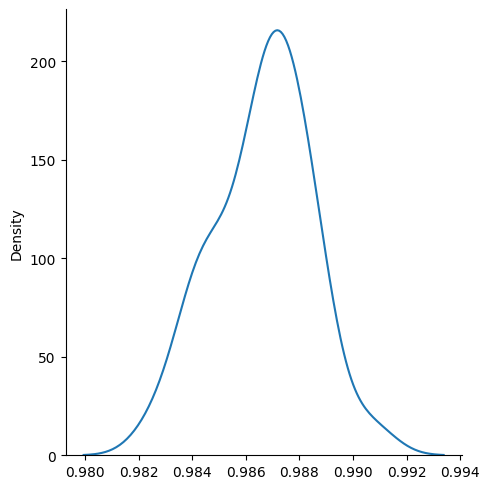

In [13]:
sns.displot(resultados_arvores, kind='kde');

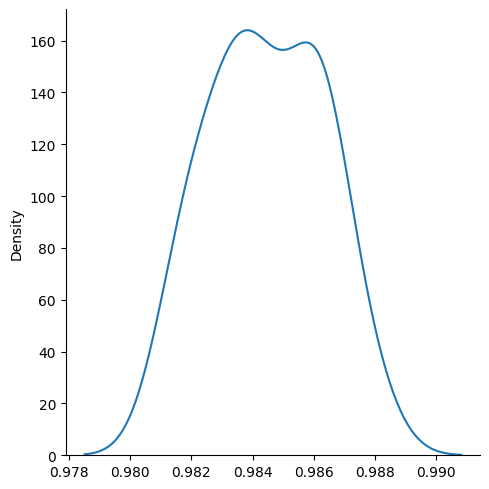

In [14]:
sns.displot(resultados_random_forest, kind='kde');

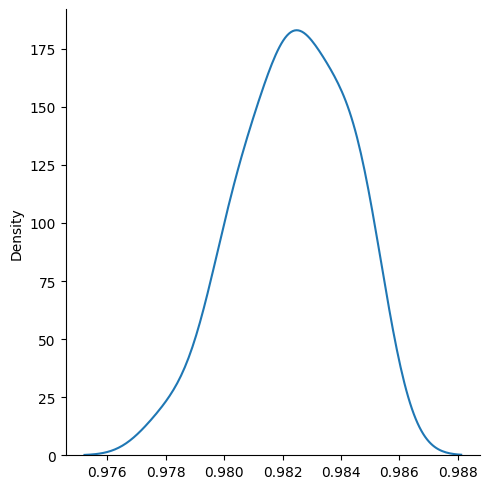

In [15]:
sns.displot(resultados_knn, kind='kde');

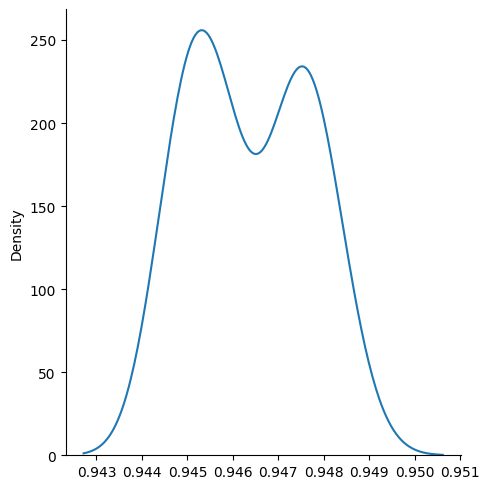

In [16]:
sns.displot(resultados_logistica, kind='kde');

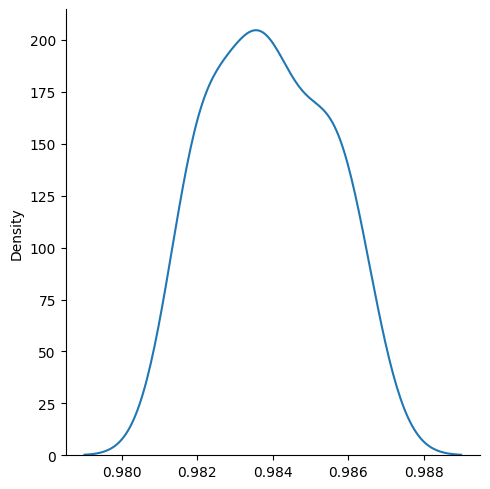

In [17]:
sns.displot(resultados_svm, kind='kde');

## Teste de Hipótese com ANOVA e Tukey

In [18]:
_, p = f_oneway(
    resultados_arvores,
    resultados_random_forest,
    resultados_knn,
    resultados_logistica,
    resultados_svm
)
p

np.float64(1.8979763964380585e-139)

In [19]:
alpha = 0.05
if p <= alpha:
    print('Hipótese nula rejeitada. Dados são diferentes')
else:
    print('Hipótese alternativa rejeitada. Resultados são iguais')

Hipótese nula rejeitada. Dados são diferentes


In [20]:
resultados_algoritmos = {
    "accuracy": np.concatenate([
        resultados_arvores,
        resultados_random_forest,
        resultados_knn,
        resultados_logistica,
        resultados_svm]),
    "algoritmo": [
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'arvore', 'arvore', 'arvore', 'arvore', 'arvore',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest', 'random_forest', 'random_forest',
            'random_forest', 'random_forest',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'knn', 'knn', 'knn', 'knn', 'knn',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'logistica', 'logistica', 'logistica', 'logistica', 'logistica',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
            'svm', 'svm', 'svm', 'svm', 'svm',
    ]
}

In [21]:
resultados_df = pd.DataFrame(resultados_algoritmos)
resultados_df

,accuracy,algoritmo
0,0.987333,arvore
1,0.987333,arvore
2,0.988667,arvore
3,0.986667,arvore
4,0.984667,arvore
...,...,...
145,0.983333,svm
146,0.985333,svm
147,0.983333,svm
148,0.984000,svm


In [22]:
compara_algoritimos = MultiComparison(
    resultados_df['accuracy'], resultados_df['algoritmo']
)
teste_estatistico = compara_algoritimos.tukeyhsd()
print(teste_estatistico)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
       arvore           knn  -0.0042    0.0 -0.0054 -0.0031   True
       arvore     logistica  -0.0402    0.0 -0.0414 -0.0391   True
       arvore random_forest  -0.0022    0.0 -0.0033  -0.001   True
       arvore           svm  -0.0027    0.0 -0.0039 -0.0015   True
          knn     logistica   -0.036    0.0 -0.0372 -0.0348   True
          knn random_forest   0.0021    0.0  0.0009  0.0033   True
          knn           svm   0.0015 0.0055  0.0003  0.0027   True
    logistica random_forest   0.0381    0.0  0.0369  0.0393   True
    logistica           svm   0.0375    0.0  0.0363  0.0387   True
random_forest           svm  -0.0006 0.6682 -0.0018  0.0006  False
------------------------------------------------------------------


In [23]:
resultados.mean()

Arvore                0.986622
Random Forest         0.984467
KNN                   0.982378
Regresão Logistica    0.946378
SVM                   0.983889
dtype: float64

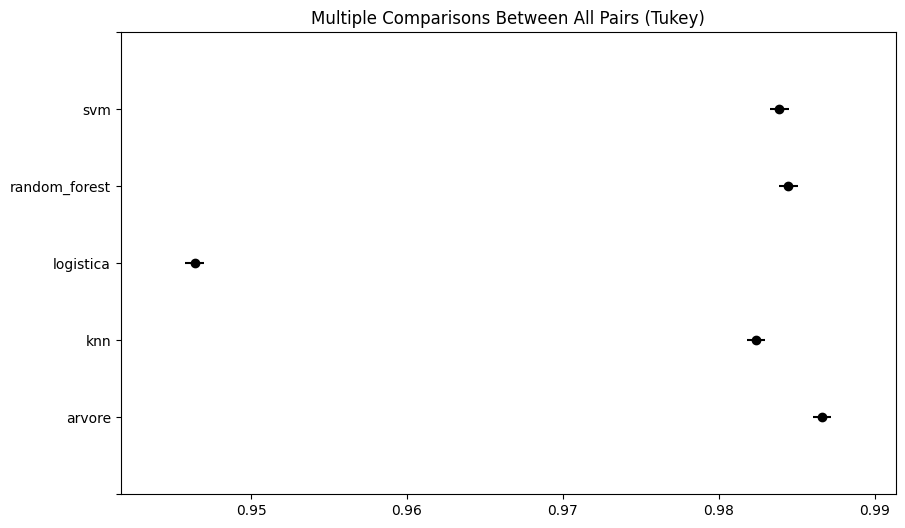

In [24]:
teste_estatistico.plot_simultaneous();

## Salva um Classificador já treinado

In [25]:
with open(os.path.join(DRIVE_DIRECTORY, "credit.pkl"), "rb") as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = (
        pickle.load(f)
    )

In [26]:
X_credit = np.concatenate((X_credit_treinamento, X_credit_teste), axis=0)
y_credit = np.concatenate((y_credit_treinamento, y_credit_teste), axis=0)
X_credit, y_credit

(array([[-1.3754462 ,  0.50631087,  0.10980934],
        [ 1.45826409, -1.6489393 , -1.21501497],
        [-0.79356829,  0.22531191, -0.43370226],
        ...,
        [ 1.37445674, -1.05746281, -1.12564819],
        [-1.57087737, -0.63488173, -0.36981671],
        [-1.03572293, -0.93978122,  0.04244312]], shape=(2000, 3)),
 array([0, 0, 0, ..., 0, 1, 1], shape=(2000,)))

In [27]:
classificador_arvore = DecisionTreeClassifier(
    criterion='entropy', min_samples_leaf=1,
    min_samples_split=5, splitter='best'
)
classificador_arvore.fit(X_credit, y_credit)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [28]:
classificador_svm = SVC(C=4.0, kernel='rbf', tol=0.1)
classificador_svm.fit(X_credit, y_credit)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",4.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.1
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
classificador_floresta = RandomForestClassifier(
    n_estimators=19, criterion='entropy',
    min_samples_leaf=1, min_samples_split=5
)
classificador_floresta.fit(X_credit, y_credit)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",19
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [30]:
pickle.dump(classificador_arvore, open('Avore.sav', 'wb'))
pickle.dump(classificador_svm, open('SVM.sav', 'wb'))
pickle.dump(classificador_floresta, open('floresta.sav', 'wb'))

## Carregar um classificador já treinado

In [31]:
arvore = pickle.load(open('Avore.sav', 'rb'))
svm = pickle.load(open('SVM.sav',  'rb'))
floresta = pickle.load(open('floresta.sav',  'rb'))

In [32]:
novo_registro = X_credit[0]
novo_registro = novo_registro.reshape(1, -1)

In [33]:
arvore.predict(novo_registro)

array([0])

In [34]:
svm.predict(novo_registro)

array([0])

In [35]:
floresta.predict(novo_registro)

array([0])